<a href="https://colab.research.google.com/github/uditanshu01/Machine-Learning/blob/Linear-Regression/Heightprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [24]:
df=pd.read_csv('/content/height-weight.csv')
df


,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


Text(0, 0.5, 'Height')

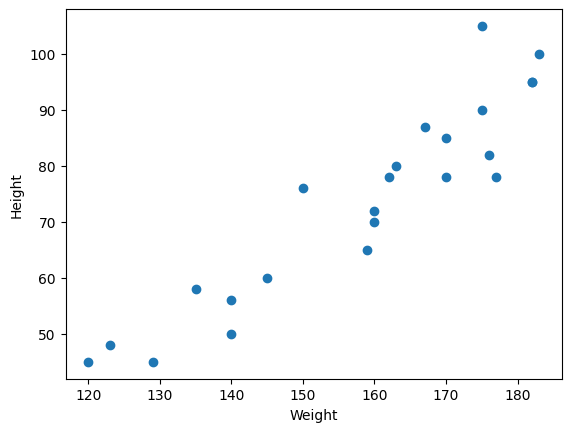

In [25]:
plt.scatter(df['Height'],df['Weight'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [26]:
x=df[['Weight']]
y=df['Height']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4,random_state=42)

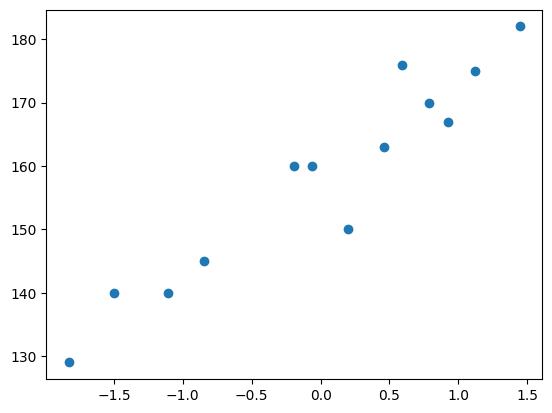

In [27]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
plt.scatter(x_train,y_train)

158.23076923076923
[14.87287783]


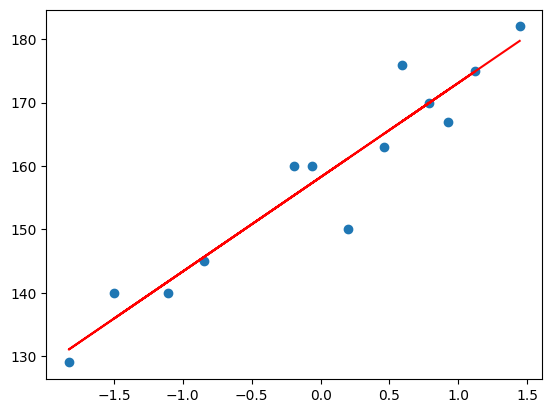

In [28]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
plt.scatter(x_train,y_train)
plt.plot(x_train,lr.predict(x_train),'r')
print(lr.intercept_)
print(lr.coef_)

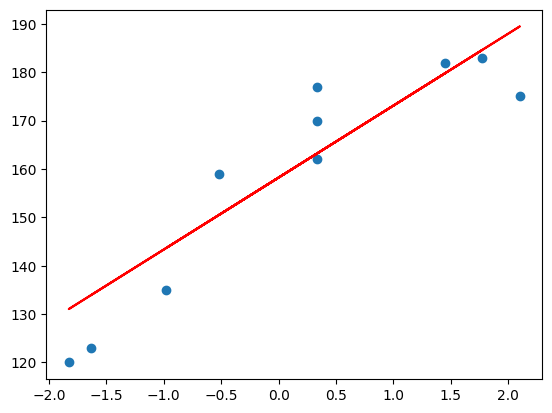

In [29]:
y_pred_test=lr.predict(x_test)
y_pred_test, y_test
plt.scatter(x_test,y_test)
plt.plot(x_test,y_pred_test,'r')

In [30]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred_test)
print("MSE:", mse, "MAE:", mae, "RMSE:", rmse, "R2:", score)


MSE: 84.58201117617313 MAE: 7.934706300091304 RMSE: 9.196847893499877 R2: 0.8375422342190897


1. MSE — Mean Squared Error
mse = mean_squared_error(y_test, y_pred_test)

💡 Idea

Average of (actual − predicted)²

Formula
𝑀
𝑆
𝐸
=
1
𝑛
∑
(
𝑦
−
𝑦
^
)
2
MSE=
n
1
	​

∑(y−
y
^
	​

)
2
✅ Significance

Punishes large errors heavily (because of square)

Good when big mistakes are very bad

Always ≥ 0

Lower = better


Adjusted r2 score
adjusted r2= 1-[(1-r2)*(n-1)/(n-k-1)]


In [ ]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)


0.7394182684592242

COLUMNS contains all the columns both input and outputs

FEATURES are only the input columns

In [31]:
scaled_weight=sc.transform([[80]])
print("NOW THIS 80 KG WEIGHT LOOK LIKES 0.32 AFTER SCALING",scaled_weight)
#NOW PEFORM THE PREDICTION
print(lr.predict(scaled_weight))
#example student of class has wieght 80 90 70
num=int(input("Enter the number of students"))
weights=[]
for i in range(num):
  w=float(input(f"Enter the weight of {i+1}:" ))
  weights.append([w])

scaled_values=sc.transform(weights)
lr.predict(scaled_values)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


NOW THIS 80 KG WEIGHT LOOK LIKES 0.32 AFTER SCALING [[0.4633247]]
[165.12174089]
Enter the number of students3
Enter the weight of 1:60
Enter the weight of 2:58
Enter the weight of 3:62


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([145.64725576, 143.69980724, 147.59470427])

15    13.825708
9      6.825708
0    -11.041392
8      2.272395
17     8.484123
12   -14.464847
1     -8.699807
13    -1.596226
5     -1.174292
2    -10.962565
Name: Height, dtype: float64


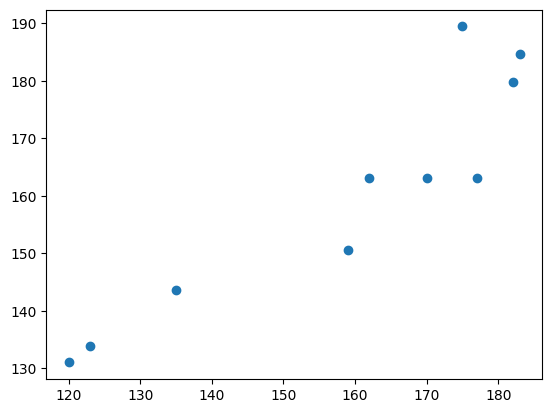

In [34]:
#ASSUMPTIONS
plt.scatter(y_test,y_pred_test)
#RESIDUALS
residuals=y_test-y_pred_test
print(residuals)

/tmp/ipython-input-640955638.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

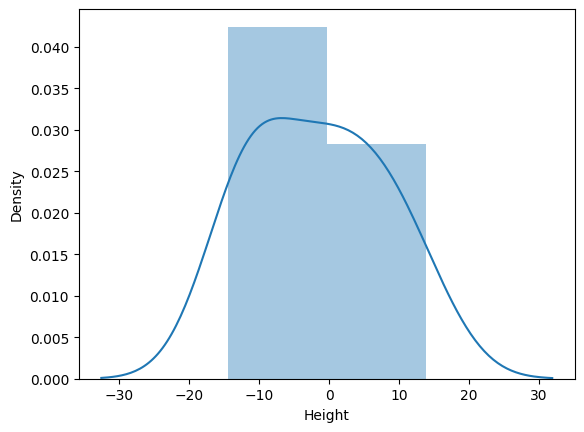

In [35]:
#plot the esiduals
import seaborn as sns
sns.distplot(residuals,kde=True)

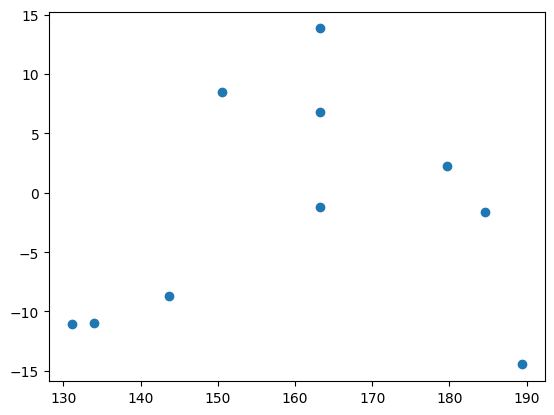

In [36]:
#Scatter plot with respect to prediction and residuals
plt.scatter(y_pred_test,residuals)
plt.show()
